In [ ]:
import pandas as pd
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import pandas as pd

In [ ]:
data=pd.read_csv("/home/student/HousingData.csv")
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [ ]:
data.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

In [ ]:
# Finding out the correlation between the features
corr = data.corr()
corr.shape

(14, 14)

<Axes: >

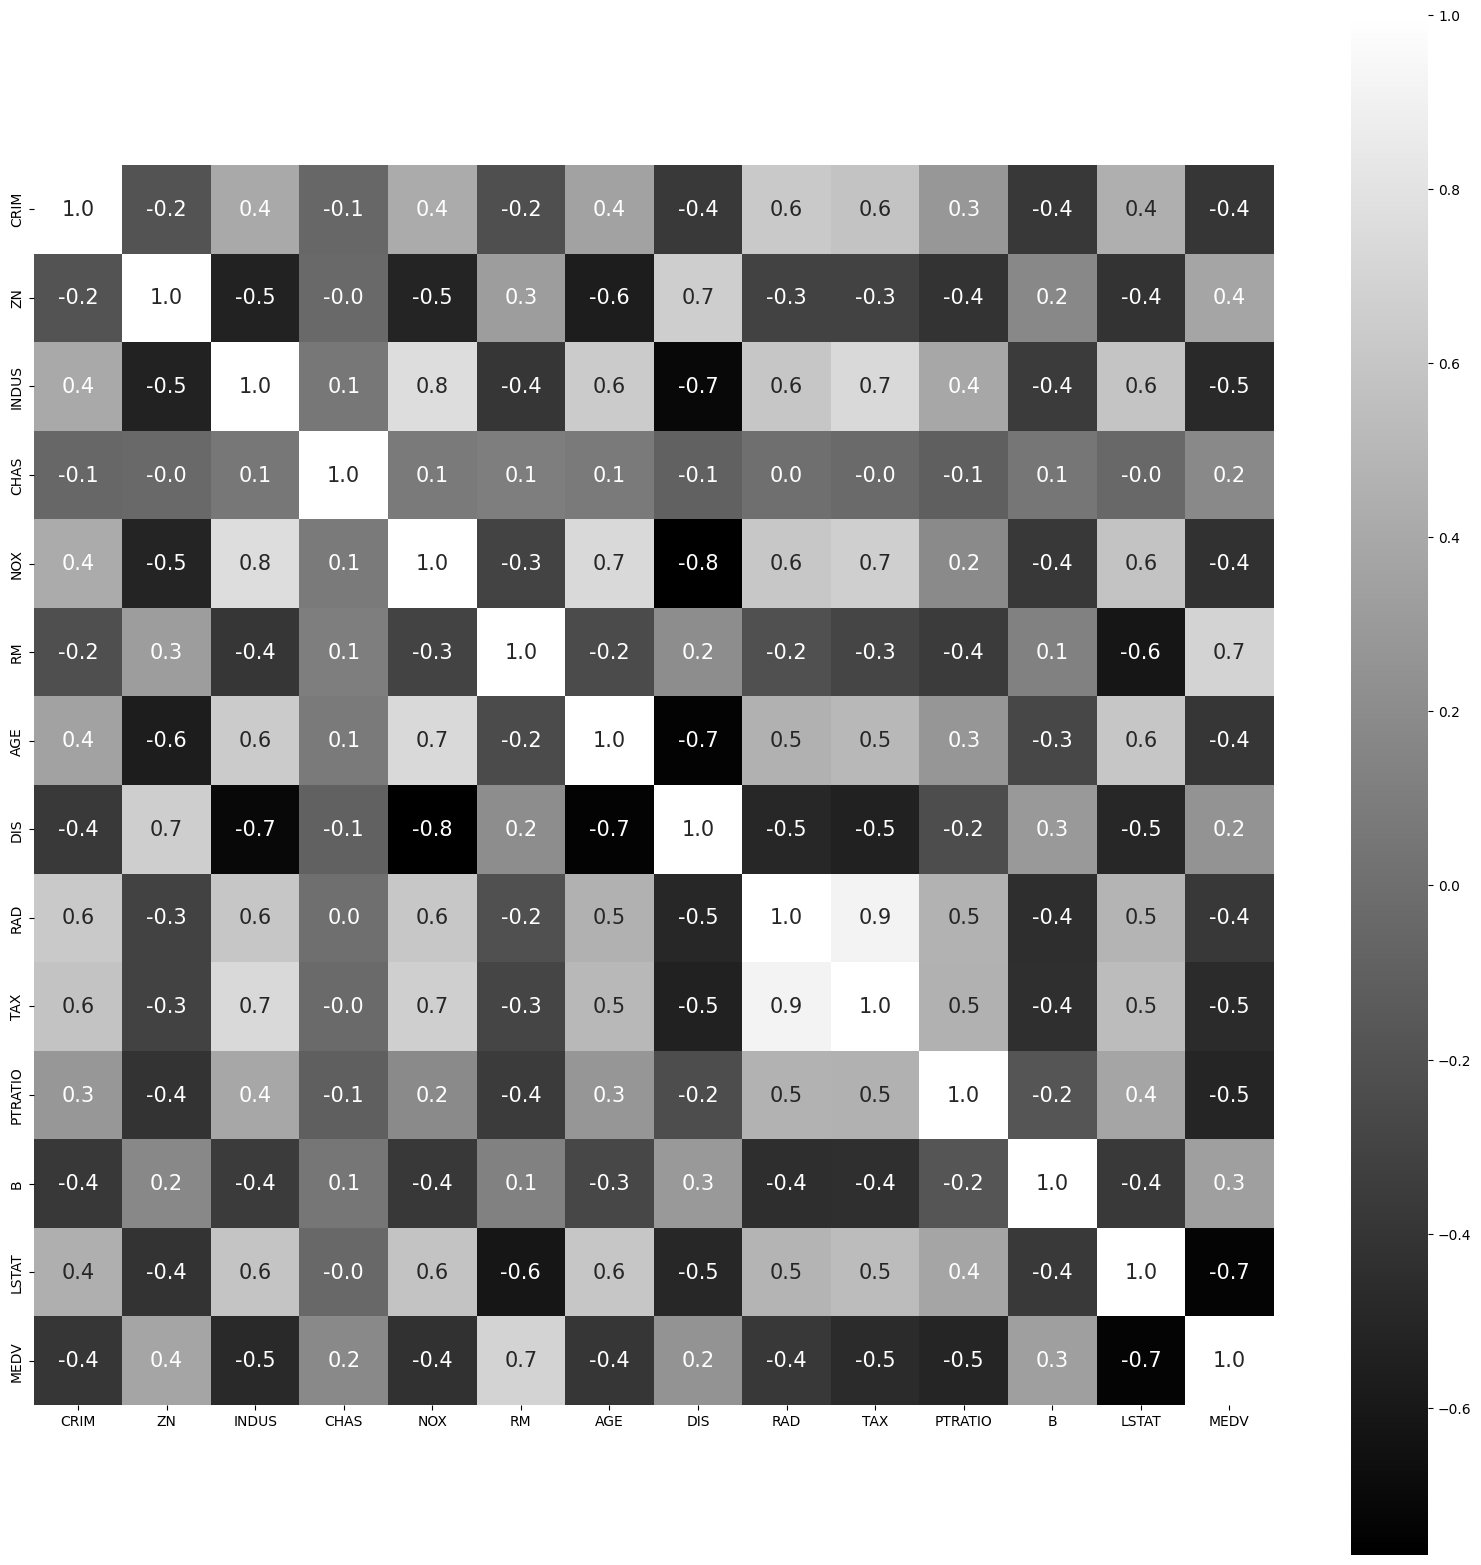

In [ ]:
# Plotting the heatmap of correlation between features
plt.figure(figsize=(20,20))
sns.heatmap(corr, cbar=True, square= True, fmt='.1f', annot=True, annot_kws={'size':15}, cmap='gray')

In [ ]:
X =data.drop(['MEDV'], axis = 1)# data['area']#
y = data['MEDV']

In [ ]:
X

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48


In [ ]:
X.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT'],
      dtype='object')

In [ ]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64

In [ ]:
y.describe()

count    506.000000
mean      22.532806
std        9.197104
min        5.000000
25%       17.025000
50%       21.200000
75%       25.000000
max       50.000000
Name: MEDV, dtype: float64

In [ ]:
# Splitting to training and testing data

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 4)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# Instantiate the scaler and fit to training dataset, X_train
scaler = MinMaxScaler()
scaler.fit(X_train)

# Replace unscaled values with scaled values
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Sequential()
model.add(Dense(64, input_dim =13, activation = 'relu'))
model.add(Dropout(0.15))
model.add(Dense(64, activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(40, activation = 'relu'))
model.add(Dropout(0.15))
model.add(Dense(54, activation = 'relu'))
model.add(Dropout(0.18))
model.add(Dense(1))

/home/student/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['mse', 'mae'])

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop("MEDV", axis=1)
y = data["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

In [ ]:
print(X_train.shape)
print(y_train.shape)

(404, 13)
(404,)


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200
)

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 142.6199 - mae: 9.4254 - mse: 142.6199 - val_loss: 106.6783 - val_mae: 7.9187 - val_mse: 106.6783
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 126.8631 - mae: 8.5743 - mse: 126.8631 - val_loss: 128.0549 - val_mae: 9.0261 - val_mse: 128.0549
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 177.2400 - mae: 9.8127 - mse: 177.2400 - val_loss: 115.1084 - val_mae: 8.3261 - val_mse: 115.1084
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 178.4317 - mae: 9.7368 - mse: 178.4317 - val_loss: 99.8471 - val_mae: 7.5087 - val_mse: 99.8471
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 150.4378 - mae: 9.3221 - mse: 150.4378 - val_loss: 108.1446 - val_mae: 7.9762 - val_mse: 108.1446
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 158.0248 - mae: 9.7353 - mse: 158.0248 - val_loss: 127.6082 - val_mae: 8.9717 - val_mse: 127.6082
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - 

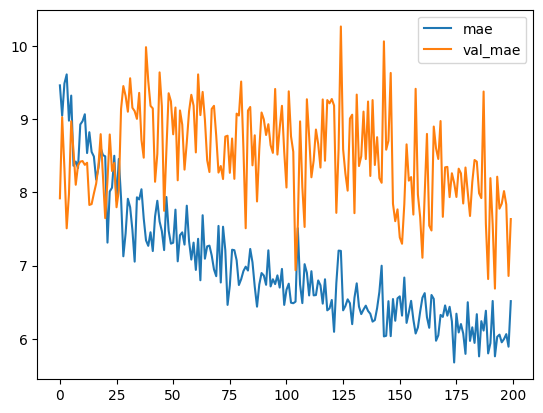

In [ ]:
import matplotlib.pyplot as plt

#plot the loss and validation loss of the dataset
plt.plot(history.history['mae'], label='mae')
plt.plot(history.history['val_mae'], label='val_mae')

plt.legend()

In [ ]:
scores = model.evaluate(X_test, y_test, verbose = 0)

print('Mean Squared Error : ', scores[1])
print('Mean Absolute Error : ', scores[2])

Mean Squared Error :  100.99047088623047
Mean Absolute Error :  7.6757493019104


In [ ]:
Y_pred = model.predict(X_test)
Y_pred

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


array([[13.263922 ],
       [ 9.791531 ],
       [13.814254 ],
       [14.196954 ],
       [13.229843 ],
       [18.786379 ],
       [14.067928 ],
       [ 5.988801 ],
       [15.825493 ],
       [12.452485 ],
       [12.037558 ],
       [19.393347 ],
       [16.593767 ],
       [16.80482  ],
       [18.600193 ],
       [ 6.8712754],
       [24.912794 ],
       [26.375288 ],
       [20.532797 ],
       [15.261092 ],
       [20.82239  ],
       [20.45106  ],
       [16.814692 ],
       [17.987673 ],
       [19.381758 ],
       [11.886977 ],
       [11.750059 ],
       [12.077577 ],
       [11.136311 ],
       [11.794784 ],
       [13.337718 ],
       [15.517249 ],
       [18.076698 ],
       [10.146165 ],
       [ 6.825445 ],
       [21.423166 ],
       [17.709797 ],
       [15.676093 ],
       [15.241128 ],
       [17.5588   ],
       [15.609125 ],
       [18.149319 ],
       [15.536181 ],
       [18.064938 ],
       [14.404902 ],
       [ 9.497614 ],
       [14.371793 ],
       [13.60

In [ ]:
from sklearn.metrics import r2_score

print('r2 score: ', r2_score(y_test,Y_pred))

r2 score:  -0.2993368356762214


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


[]

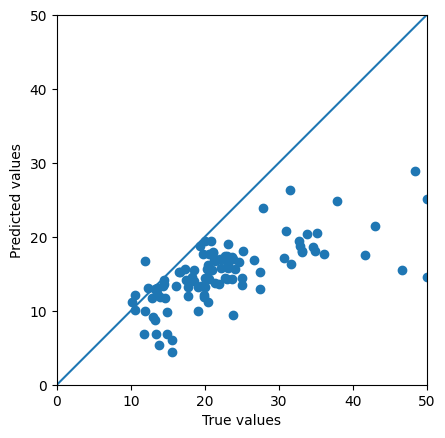

In [ ]:
Y_pred = model.predict(X_test)

a = plt.axes(aspect='equal')

plt.xlabel('True values')
plt.ylabel('Predicted values')
plt.xlim([0, 50])
plt.ylim([0, 50])
plt.plot([0, 50], [0,50])
plt.scatter(y_test,Y_pred)
plt.plot()

In [ ]:
# Import library for Linear Regression
from sklearn.linear_model import LinearRegression

In [ ]:
# Create a Linear regressor
lm = LinearRegression()

# Train the model using the training sets
lm.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# Value of y intercept
lm.intercept_

31.935288544065862

In [ ]:
#Converting the coefficient values to a dataframe
coeffcients = pd.DataFrame([X.columns,lm.coef_]).T
coeffcients = coeffcients.rename(columns={0: 'Attribute', 1: 'Coefficients'})
coeffcients

,Attribute,Coefficients
0,CRIM,-0.111882
1,ZN,0.039549
2,INDUS,-0.029851
3,CHAS,3.790129
4,NOX,-16.289626
5,RM,4.193762
6,AGE,-0.01314
7,DIS,-1.500032
8,RAD,0.247104
9,TAX,-0.008781


In [ ]:
# Model prediction on train data
y_pred = lm.predict(X_train)

In [ ]:
# Model Evaluation
print('R^2:',metrics.r2_score(y_train, y_pred))
print('Adjusted R^2:',1 - (1-metrics.r2_score(y_train, y_pred))*(len(y_train)-1)/(len(y_train)-X_train.shape[1]-1))
print('MAE:',metrics.mean_absolute_error(y_train, y_pred))
print('MSE:',metrics.mean_squared_error(y_train, y_pred))
print('RMSE:',np.sqrt(metrics.mean_squared_error(y_train, y_pred)))

R^2: 0.7307149985929173
Adjusted R^2: 0.7217388318793478
MAE: 3.4101655190807807
MSE: 23.18647737860549
RMSE: 4.815233886178893


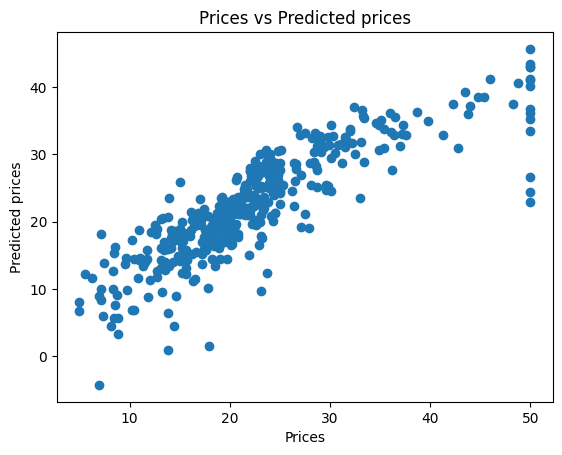

In [ ]:
# Visualizing the differences between actual prices and predicted values
plt.scatter(y_train, y_pred)
plt.xlabel("Prices")
plt.ylabel("Predicted prices")
plt.title("Prices vs Predicted prices")
plt.show()

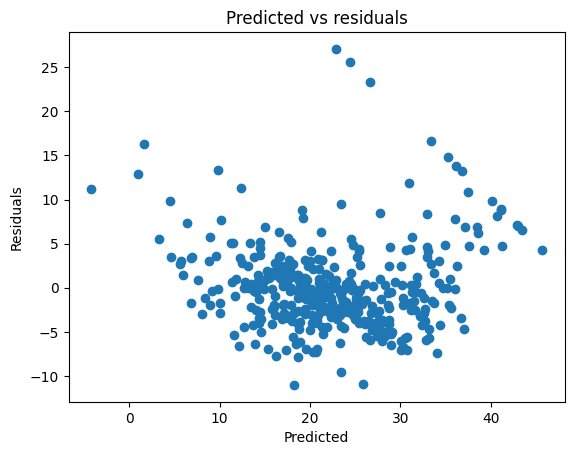

In [ ]:
# Checking residuals
plt.scatter(y_pred,y_train-y_pred)
plt.title("Predicted vs residuals")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

/tmp/ipykernel_3126/3326403628.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train-y_pred)


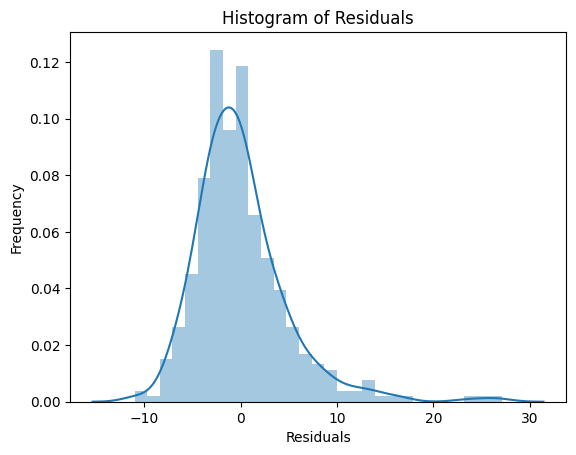

In [ ]:
# Checking Normality of errors
sns.distplot(y_train-y_pred)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Predicting Test data with the model
y_test_pred = lm.predict(X_test)

In [ ]:
# Model Evaluation
acc_linreg = metrics.r2_score(y_test, y_test_pred)
print('R^2:', acc_linreg)
print('Adjusted R^2:',1 - (1-metrics.r2_score(y_test, y_test_pred))*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))
print('MAE:',metrics.mean_absolute_error(y_test, y_test_pred))
print('MSE:',metrics.mean_squared_error(y_test, y_test_pred))
print('RMSE:',np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))

R^2: 0.7286623328299486
Adjusted R^2: 0.6885783592707364
MAE: 3.086487994488598
MSE: 21.089618468287252
RMSE: 4.592343461489706
